In [1]:
!pip install numpy
!pip install matplotlib
!pip install pandas
!pip install scikit-learn
!pip install seaborn

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

In [79]:
titanic = pd.read_csv('titanic.csv')

In [80]:
titanic.count()

survived       891
pclass         891
sex            891
age            714
sibsp          891
parch          891
fare           891
embarked       889
class          891
who            891
adult_male     891
deck           203
embark_town    889
alive          891
alone          891
dtype: int64

In [81]:
titanic.isnull().sum()  # finding missing values

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [82]:
features=['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'alone'] # drop embark,deck features
target= 'survived'

In [83]:
X=titanic[features]
y=titanic[target]

In [84]:
y.value_counts()  # calculate how many survived and how many not survived 

survived
0    549
1    342
Name: count, dtype: int64

In [85]:
#Split data into training and testing data 

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [87]:
# Divide features into numerical and categorical

In [88]:
numerical_features = X_train.select_dtypes(
    include=['number']
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

In [89]:
# start preprocessing pipelines

In [90]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # any NaN variable will be changed by median 
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[     
    ('imputer', SimpleImputer(strategy='most_frequent')),  # if there is NAN value change it with the most_frequent value (male,female,male,male)=male
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # convert into numbers can model understand
])

In [91]:
# After fixing missing values ,combine it using ColumnTransformer

In [92]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),   
        ('cat', categorical_transformer, categorical_features)
    ])

In [93]:
param_grid = {
    'classifier__n_estimators': [50, 100],     # using difrrent values to test the accuracy
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

In [94]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [95]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [96]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['pclass',
                                                                          'age',
                                                                          'sibsp',
                                                                          'parch',
                                                                          'fare']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'class',
                                                                          'who'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [50, 100]},
             scoring='accuracy')

In [97]:
grid_search.best_params_

{'classifier__max_depth': 10,
 'classifier__min_samples_split': 5,
 'classifier__n_estimators': 50}

In [98]:
grid_search.best_score_    #the best avarege accuracy during Cross Validation

np.float64(0.8343445287107258)

In [99]:
y_pred = grid_search.predict(X_test)

In [100]:
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.8156424581005587


In [101]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



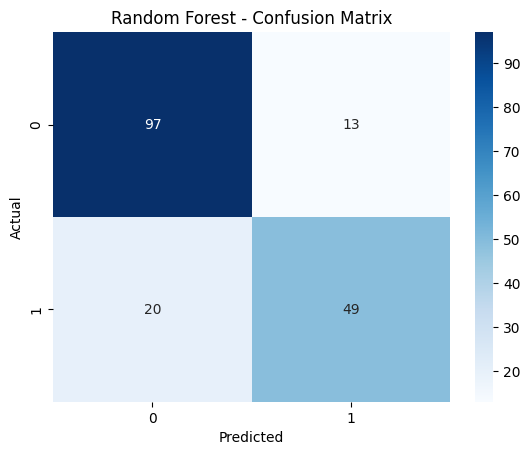

In [102]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [103]:
# trying  diffrent model to try out different models and even revisit the data analysis to improve your model performance

In [104]:
# Replace RandomForestClassifier with LogisticRegression
pipeline.set_params(classifier=LogisticRegression(random_state=42))

# update the model's estimator to use the new pipeline
grid_search.estimator = pipeline

# Define a new grid with Logistic Regression parameters
param_grid = {
    # 'classifier__n_estimators': [50, 100],
    # 'classifier__max_depth': [None, 10, 20],
    # 'classifier__min_samples_split': [2, 5],
    'classifier__solver' : ['liblinear'],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight' : [None, 'balanced']
}

grid_search.param_grid = param_grid

# Fit the updated pipeline with Logistic Regression
grid_search.fit(X_train, y_train)

# Make predictions
y_pred = grid_search.predict(X_test)

In [105]:
print(classification_report(y_test, y_pred))    

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



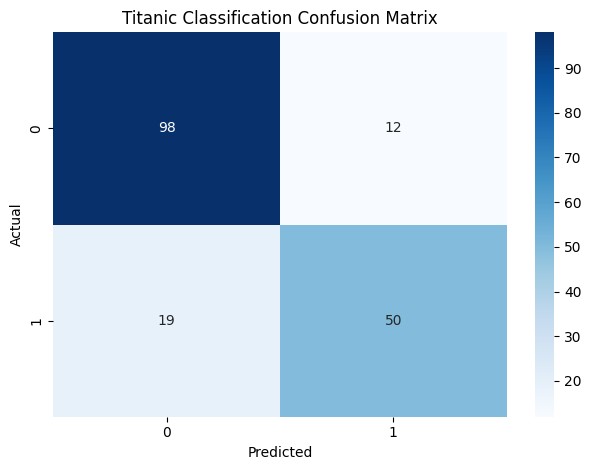

In [106]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')

# Set the title and labels
plt.title('Titanic Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.show()

In [107]:
coefficients = grid_search.best_estimator_.named_steps['classifier'].coef_[0]

# Combine numerical and categorical feature names
numerical_feature_names = numerical_features
categorical_feature_names = (grid_search.best_estimator_.named_steps['preprocessor']
                                     .named_transformers_['cat']
                                     .named_steps['onehot']
                                     .get_feature_names_out(categorical_features)
                            )
feature_names = numerical_feature_names + list(categorical_feature_names)

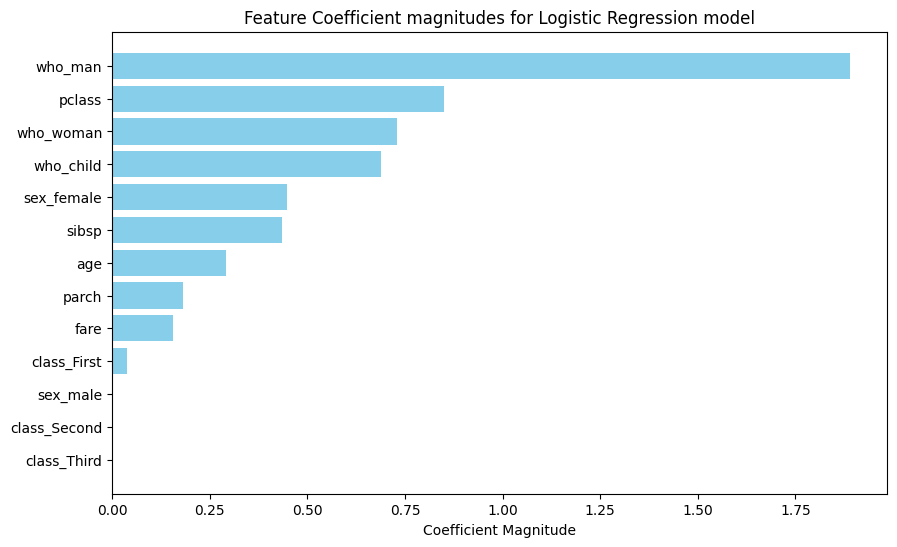


Test set accuracy: 82.68%


In [108]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False, key=abs)  # Sort by absolute values

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Coefficient'].abs(), color='skyblue')
plt.gca().invert_yaxis()
plt.title('Feature Coefficient magnitudes for Logistic Regression model')
plt.xlabel('Coefficient Magnitude')
plt.show()

# Print test score
test_score = grid_search.best_estimator_.score(X_test, y_test)
print(f"\nTest set accuracy: {test_score:.2%}")

In [112]:
new_person = pd.DataFrame({
    'pclass': [3],
    'sex': ['female'],
    'age': 40,
    'sibsp': [0],
    'parch': [0],
    'fare': [100],
    'class': ['second'],
    'who': ['woman'],
    'adult_male': [True],
    'alone': [False]
})

new_person

,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,alone
0,3,female,40,0,0,100,second,woman,True,False


In [113]:
prediction = grid_search.predict(new_person)

print("Prediction:", prediction)

Prediction: [1]


In [114]:
prediction = grid_search.predict(new_person)[0]

if prediction == 1:
    print("The person is predicted to survive.")
else:
    print("The person is predicted not to survive.")

The person is predicted to survive.


In [115]:
import joblib

joblib.dump(grid_search, "titanic_model.pkl")

['titanic_model.pkl']